Mounted at /content/drive
Device: cuda
GPU   : Tesla T4


100%|██████████| 169M/169M [00:00<00:00, 257MB/s]



Train: 40,000 | Val: 10,000 | Test: 10,000


  resnet50


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

  Parameters: 23,712,932

  Epoch  1/5  | Train  loss 2.4484  acc 45.29%| Val  loss 0.9199  acc 72.68%| 419.5s
  Epoch  2/5  | Train  loss 0.9191  acc 73.74%| Val  loss 0.7010  acc 78.37%| 424.2s
  Epoch  3/5  | Train  loss 0.6912  acc 79.57%| Val  loss 0.6337  acc 80.14%| 425.1s
  Epoch  4/5  | Train  loss 0.5806  acc 82.53%| Val  loss 0.6020  acc 80.97%| 422.5s
  Epoch  5/5  | Train  loss 0.5271  acc 84.06%| Val  loss 0.5929  acc 81.35%| 423.8s

  Evaluating on test set...
  Accuracy  : 82.22%
  Precision : 0.8229  |  Recall: 0.8222  |  F1: 0.8209
  Inf. time : 30.76s  |  Train time: 2115s total


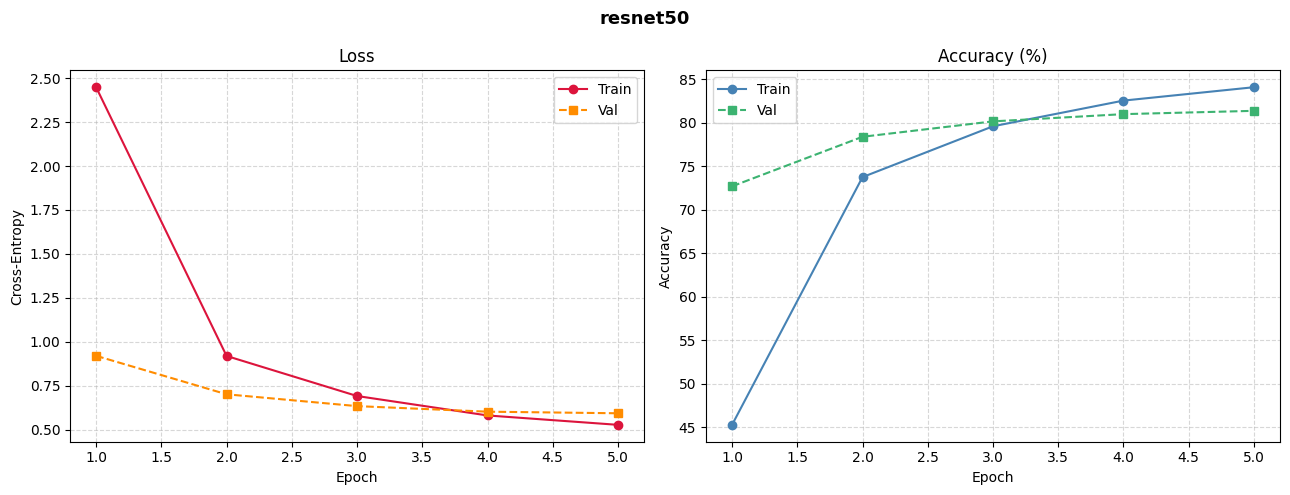


  vit_base_patch16_224


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

  Parameters: 85,875,556

  Epoch  1/5  | Train  loss 1.7649  acc 55.48%| Val  loss 0.8400  acc 75.12%| 1406.5s
  Epoch  2/5  | Train  loss 0.5767  acc 82.64%| Val  loss 0.6756  acc 79.91%| 1406.5s
  Epoch  3/5  | Train  loss 0.2791  acc 91.10%| Val  loss 0.5870  acc 83.05%| 1405.3s
  Epoch  4/5  | Train  loss 0.1027  acc 96.46%| Val  loss 0.5605  acc 85.82%| 1405.6s
  Epoch  5/5  | Train  loss 0.0301  acc 99.04%| Val  loss 0.5289  acc 87.22%| 1406.5s

  Evaluating on test set...
  Accuracy  : 87.73%
  Precision : 0.8801  |  Recall: 0.8773  |  F1: 0.8778
  Inf. time : 107.46s  |  Train time: 7031s total


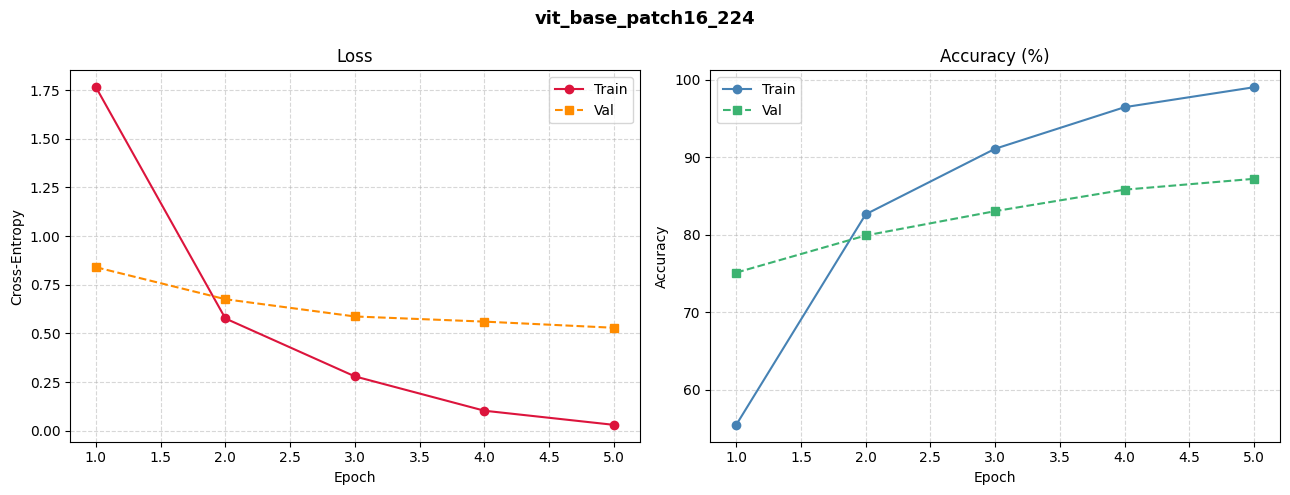


  swin_tiny_patch4_window7_224


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

  Parameters: 27,596,254

  Epoch  1/5  | Train  loss 1.3080  acc 64.86%| Val  loss 0.7738  acc 76.77%| 537.6s
  Epoch  2/5  | Train  loss 0.5905  acc 82.26%| Val  loss 0.6139  acc 81.53%| 538.1s
  Epoch  3/5  | Train  loss 0.3581  acc 88.66%| Val  loss 0.5571  acc 83.73%| 535.9s
  Epoch  4/5  | Train  loss 0.2003  acc 93.79%| Val  loss 0.4922  acc 85.69%| 536.2s
  Epoch  5/5  | Train  loss 0.1239  acc 96.53%| Val  loss 0.4662  acc 86.59%| 537.4s

  Evaluating on test set...
  Accuracy  : 87.23%
  Precision : 0.8738  |  Recall: 0.8723  |  F1: 0.8723
  Inf. time : 44.69s  |  Train time: 2685s total


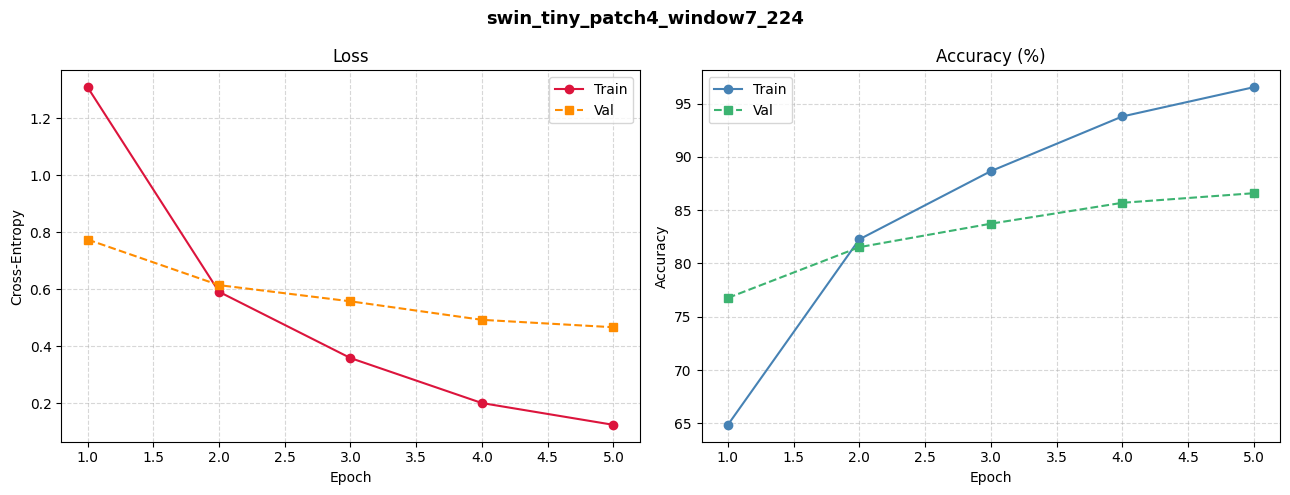


                       Model Accuracy (%) Precision Recall F1-Score Best Val Acc (%) Parameters Train Time (s) Inference (s)
                    resnet50        82.22    0.8229 0.8222   0.8209            81.35 23,712,932           2115         30.76
        vit_base_patch16_224        87.73    0.8801 0.8773   0.8778            87.22 85,875,556           7031        107.46
swin_tiny_patch4_window7_224        87.23    0.8738 0.8723   0.8723            86.59 27,596,254           2685         44.69


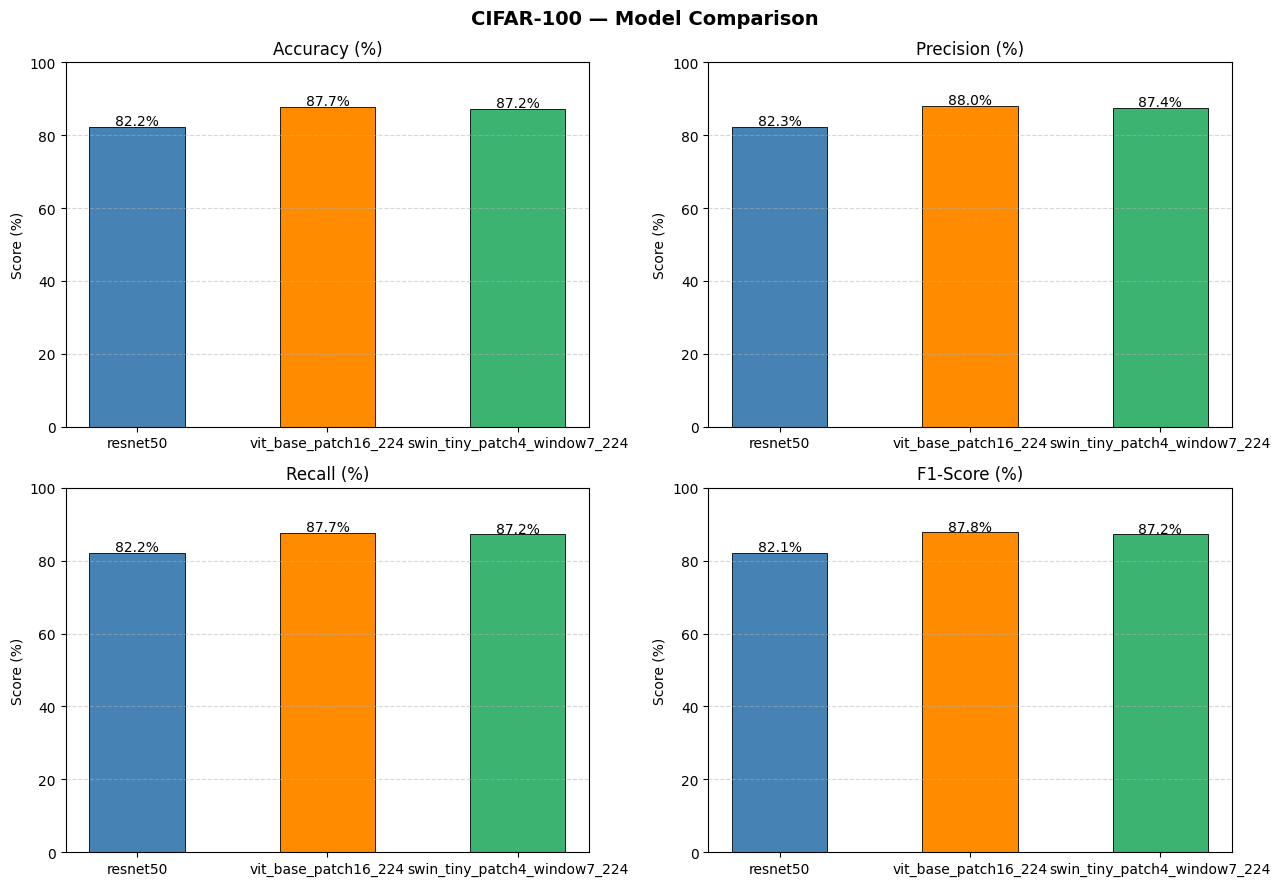

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import timm
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, confusion_matrix, precision_recall_fscore_support
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

warnings.filterwarnings("ignore")

# Configuration
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR    = "./data"
OUTPUT_DIR = "/content/drive/MyDrive/DeepLearningAssignment"
NUM_CLASSES = 100
IMAGE_SIZE  = 224   # ViT and Swin both require 224×224
BATCH_SIZE  = 32
NUM_EPOCHS  = 5
LR          = 1e-4

MODELS = [
    "resnet50",
    "vit_base_patch16_224",
    "swin_tiny_patch4_window7_224",
]

# ImageNet stats — valid here because we use ImageNet pre-trained weights
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU   : {torch.cuda.get_device_name(0)}")


# Data

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Load the 50k training images twice — once per transform — then slice by index.
# random_split() can't give each split a different transform, so this is the
# correct approach to prevent augmentation leaking into validation.
datasets.CIFAR100.url = "https://huggingface.co/datasets/nakroy/cifar100-python/resolve/main/cifar-100-python.tar.gz"

train_base = datasets.CIFAR100(DATA_DIR, train=True,  download=True,  transform=train_transform)
val_base   = datasets.CIFAR100(DATA_DIR, train=True,  download=False, transform=eval_transform)
test_set   = datasets.CIFAR100(DATA_DIR, train=False, download=True,  transform=eval_transform)

split       = int(0.8 * len(train_base))
all_indices = list(range(len(train_base)))
train_set   = Subset(train_base, all_indices[:split])
val_set     = Subset(val_base,   all_indices[split:])

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"\nTrain: {len(train_set):,} | Val: {len(val_set):,} | Test: {len(test_set):,}\n")


# Training helpers
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct    += logits.argmax(1).eq(labels).sum().item()
        total      += labels.size(0)

    return total_loss / len(loader), correct / total


def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
            logits  = model(images)
            total_loss += criterion(logits, labels).item()
            correct    += logits.argmax(1).eq(labels).sum().item()
            total      += labels.size(0)

    return total_loss / len(loader), correct / total


def evaluate_test_set(model, loader):
    #Returns full predictions + labels for metric computation.
    model.eval()
    all_preds, all_labels = [], []

    t0 = time.perf_counter()
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE, non_blocking=True)
            preds  = model(images).argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    inference_time = time.perf_counter() - t0

    return np.array(all_preds), np.array(all_labels), inference_time


# Plotting
def plot_training_curves(history, model_name):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(model_name, fontsize=13, fontweight="bold")

    ax1.plot(epochs, history["train_loss"], "o-", color="crimson",      label="Train")
    ax1.plot(epochs, history["val_loss"],   "s--", color="darkorange",  label="Val")
    ax1.set(title="Loss", xlabel="Epoch", ylabel="Cross-Entropy")
    ax1.legend(); ax1.grid(linestyle="--", alpha=0.5)

    train_acc = [a * 100 for a in history["train_acc"]]
    val_acc   = [a * 100 for a in history["val_acc"]]
    ax2.plot(epochs, train_acc, "o-",  color="steelblue",       label="Train")
    ax2.plot(epochs, val_acc,   "s--", color="mediumseagreen",  label="Val")
    ax2.set(title="Accuracy (%)", xlabel="Epoch", ylabel="Accuracy")
    ax2.legend(); ax2.grid(linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{model_name}_curves.png", dpi=150, bbox_inches="tight")
    plt.show()


def plot_confusion_matrix(cm, model_name):
    fig, ax = plt.subplots(figsize=(18, 16))
    sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=False, yticklabels=False, ax=ax)
    ax.set(
        title=f"Confusion Matrix — {model_name}  (100 × 100 classes)",
        xlabel="Predicted", ylabel="True",
    )
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/{model_name}_confusion_matrix.png", dpi=150, bbox_inches="tight")
    plt.close()


def plot_comparison_bars(all_results):
    names   = [r["model"] for r in all_results]
    metrics = {
        "Accuracy (%)":   [r["accuracy"] * 100  for r in all_results],
        "Precision (%)":  [r["precision"] * 100 for r in all_results],
        "Recall (%)":     [r["recall"] * 100    for r in all_results],
        "F1-Score (%)":   [r["f1"] * 100        for r in all_results],
    }
    colours = ["steelblue", "darkorange", "mediumseagreen"]

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    fig.suptitle("CIFAR-100 — Model Comparison", fontsize=14, fontweight="bold")

    for ax, (title, values) in zip(axes.flat, metrics.items()):
        bars = ax.bar(names, values, color=colours, edgecolor="black", linewidth=0.6, width=0.5)
        ax.set(title=title, ylim=(0, 100), ylabel="Score (%)")
        ax.grid(axis="y", linestyle="--", alpha=0.5)
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                    f"{val:.1f}%", ha="center", fontsize=10)

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/comparison_bars.png", dpi=150, bbox_inches="tight")
    plt.show()


# Main loop
all_results = []

for model_name in MODELS:
    print(f"\n{'='*60}")
    print(f"  {model_name}")
    print(f"{'='*60}")

    model      = timm.create_model(model_name, pretrained=True, num_classes=NUM_CLASSES).to(DEVICE)
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    criterion  = nn.CrossEntropyLoss()
    optimizer  = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

    # Cosine annealing for ViT — flat LR causes instability
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    total_train_time = 0.0

    print(f"  Parameters: {num_params:,}\n")

    for epoch in range(1, NUM_EPOCHS + 1):
        t0 = time.perf_counter()

        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss,   val_acc   = evaluate(model, val_loader)
        scheduler.step()

        epoch_time        = time.perf_counter() - t0
        total_train_time += epoch_time

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"  Epoch {epoch:>2}/{NUM_EPOCHS}  "
            f"| Train  loss {train_loss:.4f}  acc {train_acc*100:.2f}%"
            f"| Val  loss {val_loss:.4f}  acc {val_acc*100:.2f}%"
            f"| {epoch_time:.1f}s"
        )

    # Test set evaluation
    print(f"\n  Evaluating on test set...")
    preds, labels, inf_time = evaluate_test_set(model, test_loader)

    accuracy              = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
    cm                    = confusion_matrix(labels, preds)

    print(f"  Accuracy  : {accuracy*100:.2f}%")
    print(f"  Precision : {precision:.4f}  |  Recall: {recall:.4f}  |  F1: {f1:.4f}")
    print(f"  Inf. time : {inf_time:.2f}s  |  Train time: {total_train_time:.0f}s total")

    plot_training_curves(history, model_name)
    plot_confusion_matrix(cm, model_name)

    all_results.append({
        "model":       model_name,
        "accuracy":    accuracy,
        "precision":   precision,
        "recall":      recall,
        "f1":          f1,
        "params":      num_params,
        "train_time":  total_train_time,
        "inf_time":    inf_time,
        "best_val":    max(history["val_acc"]),
        "history":     history,
        "cm":          cm,
    })

    del model
    torch.cuda.empty_cache()


# Comparison table
table = pd.DataFrame([{
    "Model":             r["model"],
    "Accuracy (%)":      f"{r['accuracy']*100:.2f}",
    "Precision":         f"{r['precision']:.4f}",
    "Recall":            f"{r['recall']:.4f}",
    "F1-Score":          f"{r['f1']:.4f}",
    "Best Val Acc (%)":  f"{r['best_val']*100:.2f}",
    "Parameters":        f"{r['params']:,}",
    "Train Time (s)":    f"{r['train_time']:.0f}",
    "Inference (s)":     f"{r['inf_time']:.2f}",
} for r in all_results])

print("\n" + "="*90)
print(table.to_string(index=False))
print("="*90)

table.to_csv(f"{OUTPUT_DIR}/comparison_table.csv", index=False)
plot_comparison_bars(all_results)
